# Diffusion Models In Simulation-Based Inference: A Tutorial

This notebook tackles the following questions with a simple to understand, yet challenging enough model:

1. **What are diffusion models?**
2. **Why are diffusion models so special for SBI?**

Authored by Jonas Arruda and Stefan T. Radev

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import bayesflow as bf

import keras

import ipywidgets as widgets

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:2026-04-10 04:52:38,278:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:bayesflow:Using backend 'jax'


## Illustrating Diffusion Models Using [Inverse Kinematics](https://arxiv.org/pdf/2101.10763.pdf)

We consider a simple 3-segment planar robot arm with unknown configuration:
- one scalar **height offset** $h$,
- three **joint angles** $\alpha_1$, $\alpha_2$, $\alpha_3$.


The goal is: given an end position $\color{red}{\mathbf{x}}$ of a robot arm, infer the unknown arm configuration $\boldsymbol{\theta}=(h, \alpha_1, \alpha_2, \alpha_3)$.
Hence, we want to learn a mapping $\mathbf{x} \mapsto \boldsymbol\theta= (h, \alpha_1, \alpha_2, \alpha_3)$.

**Important:** this is a deliberately *non-identifiable* setting: different angle combinations can yield very similar end positions. That makes the inference task naturally **multimodal** and therefore a good stress test for flexible inference methods such as diffusion models.

![Example simulations of the inverse kinematics problem](https://raw.githubusercontent.com/bayesflow-org/bayesflow/main/examples/misc/diffusion/example_simulations.png)

## Solving Inverse Kinematics with BayesFlow

In [ ]:
def prior():
    """
    Generates a random draw from a 4-dimensional Gaussian prior distribution with a
    spherical covariance matrix. The parameters represent a robot's arm
    configuration, with the first parameter indicating the arm's height and the 
    remaining three are angles.

    Returns
    -------
    params : A single draw from the 4-dimensional Gaussian prior.
    """
    scales = np.array([0.25, 0.5, 0.5, 0.5])
    prior_samples = np.random.normal(loc=0, scale=scales)
    return dict(parameters=prior_samples)

In [3]:
def observation_model(parameters):
    """
    Returns the 2D coordinates of a robot arm given parameter vector.
    The first parameter represents the arm's height and the remaining three
    correspond to angles.

    Reference: https://arxiv.org/pdf/2101.10763.pdf

    Parameters
    ----------
    parameters   : The four model parameters which will determine the coordinates

    Returns
    -------
    x : The 2D coordinates of the arm
    """
    height_arm, angle_1, angle_2, angle_3 = parameters
    
    # Length of segments
    l1 = 0.5
    l2 = 0.5
    l3 = 1.0

    # Determine 2D position
    x1 = l1 * np.sin(angle_1)
    x1 += l2 * np.sin(angle_1 + angle_2)
    x1 += l3 * np.sin(angle_1 + angle_2 + angle_3) + height_arm

    x2 = l1 * np.cos(angle_1)
    x2 += l2 * np.cos(angle_1 + angle_2)
    x2 += l3 * np.cos(angle_1 + angle_2 + angle_3)
    return dict(observables=np.array([x1, x2]))

variable_names = ["height_arm", "angle_1", "angle_2", "angle_3"]
variable_names_nice = [" ".join(v.title().split('_')) for v in variable_names]

In [4]:
# we merge prior and observation model into a simulator
simulator = bf.make_simulator([prior, observation_model])

# now we create the simulator and generate training data
n_simulations = 5000
training_data = simulator.sample(n_simulations)

print(f"Generated {n_simulations} simulations")
print(f"Observables shape (robot arm endpoints): {training_data['observables'].shape}")
print(f"Parameters shape (heights and angles): {training_data['parameters'].shape}")

Generated 5000 simulations
Observables shape (robot arm endpoints): (5000, 2)
Parameters shape (heights and angles): (5000, 4)


The dataset now contains:
- `parameters`: samples from the prior (our *ground truth* parameters),
- `observables`: corresponding simulated end positions.

This is the only supervision signal used for training: there are no data beyond simulations.

Now let's train our neural estimator for 200 epochs! Runtime depends on your hardware and the first JAX compilation.


In [5]:
workflow_dm = bf.BasicWorkflow(
    simulator=simulator,
    inference_network=bf.networks.DiffusionModel(subnet_kwargs={"widths": (128,)*3}),
    inference_variables="parameters",
    inference_conditions="observables",
    standardize=None
)

In [6]:
history = workflow_dm.fit_offline(
    training_data, epochs=200, batch_size=128, validation_data=300
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 3.0760 - val_loss: 1.8313
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9144 - val_loss: 1.3238
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4062 - val_loss: 1.2499
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4637 - val_loss: 1.3187
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3817 - val_loss: 1.2121
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4565 - val_loss: 1.0411
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2709 - val_loss: 1.0329
Epoch 8/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3304 - val_loss: 1.0273
Epoch 9/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4230 - val_loss: 1.0766
Epoch 10/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4168 - val_loss: 0.9814
Epoch 11/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2678 - val_loss: 1.1346
Epoch 12/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.

INFO:bayesflow:Training completed in 35.38 seconds.


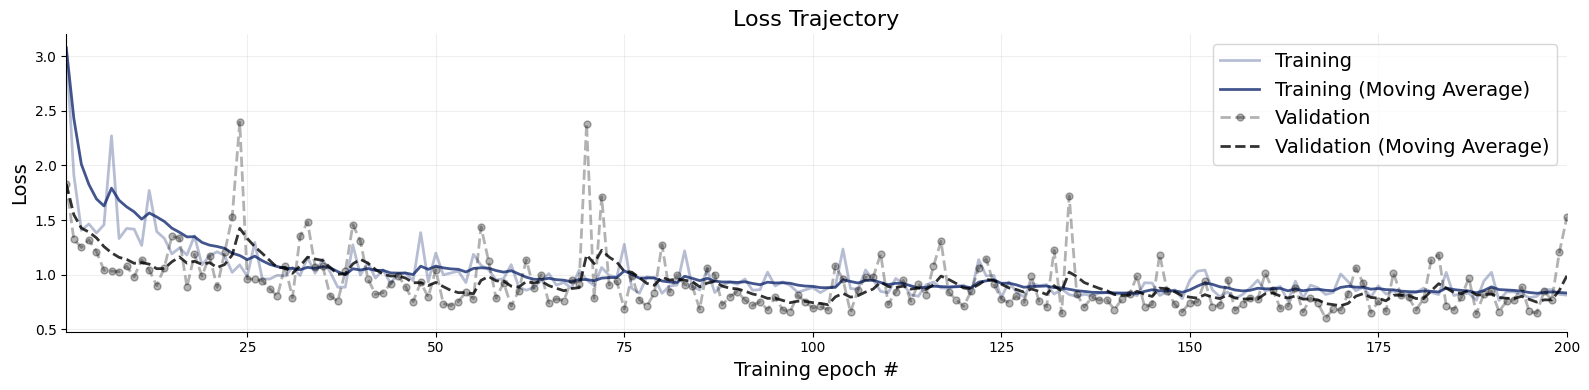

In [7]:
f = bf.diagnostics.plots.loss(history)

In [8]:
from tutorials.helpers import InverseKinematicsModel

def plot_arm_posterior(posterior_samples, obs, figsize=(8, 5)):
    _, _ax = plt.subplots(figsize=figsize)

    _m = InverseKinematicsModel(
        linecolors=[['#E7298A'], ['#E7298A'], ['#E7298A']]
    )
    _m.update_plot_ax(_ax, 
        posterior_samples["parameters"][0], 
        obs['observables'][0, ::-1], 
        exemplar_color="#E7298A"
    )
    _ax.set_title('Arm Configurations')

In [9]:
# Test amortized inference on new data
obs = {"observables": np.array([[0, 1.5]])}


# Sampling with the trained diffusion model
posterior_samples_single = workflow_dm.sample(
    conditions=obs,
    num_samples=1000
)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 3.21 seconds.


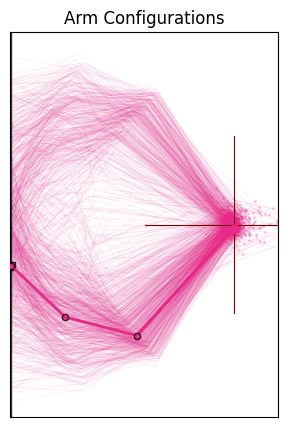

In [10]:
plot_arm_posterior(posterior_samples_single, obs)

So something seems to have been learned. We get a nice bimodal posterior!

But are we sure that this is the correct posterior? How can we make sure?

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 10.67 seconds.


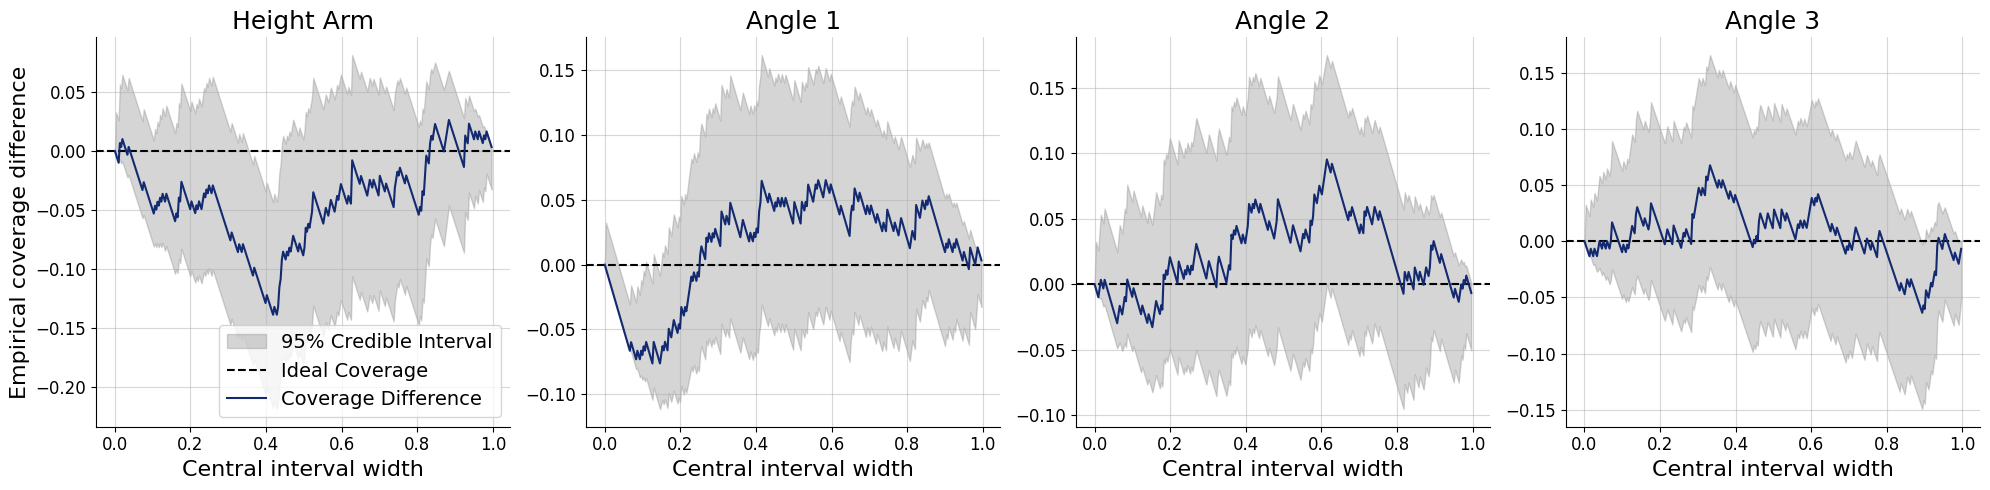

In [ ]:
test_data = simulator.sample(100)

posterior_samples_test_data = workflow_dm.sample(
    conditions=test_data,
    num_samples=300,
)

fig = bf.diagnostics.plots.coverage(
    estimates=posterior_samples_test_data,
    targets=test_data,
    variable_names=variable_names_nice
)

## 2. What are Diffusion Models?

Diffusion models are generative models that create samples by *iteratively denoising* random noise.

![Diffusion Models In Simulation-Based Inference: A Tutorial Review.](https://raw.githubusercontent.com/bayesflow-org/bayesflow/main/examples/misc/diffusion/diffusion_model_review.jpeg)

### Forward process (Training)

We start with a clean sample $\boldsymbol\theta_0$ (here: a parameter vector) and gradually add noise:

$\boldsymbol\theta_t = \alpha_t\,\boldsymbol\theta_0 + \sigma_t\,\boldsymbol\epsilon, \quad \boldsymbol\epsilon \sim \mathcal{N}(0, I)$,

where $t \in [0,1]$ is a continuous diffusion time.
At $t \approx 1$, the distribution becomes close to pure noise.
Different choices of the *noise schedule* $\alpha_t$ and $\sigma_t$ determine how fast noise is added over time and have an impact on the performance later ([Arruda et al. (2025)](https://arxiv.org/abs/2512.20685)).

So what does the network actually learn?
It gets a noisy parameter $\boldsymbol\theta_t$ and the corresponding simulation $\mathbf{x}$ and predicts the score $\nabla_{\boldsymbol\theta_t}\!\log p(\boldsymbol\theta_t\mid\mathbf{x})$.

What is this score? It is the direction in which we need to move $\boldsymbol\theta_t$ to increase its probability under the posterior.
And it can be analytically computed from the noise schedule!

### Reverse process (Inference)

The diffusion model learns how to move from noisy samples back to clean samples.
In practice, sampling is performed by solving a learned reverse-time stochastic differential equation (SDE) or an equivalent deterministic ODE.

And how? The reverse SDE/ODE is purely defined in terms of the noise schedule and the learned score!

In [13]:
t_slider_backward = widgets.FloatSlider(
    value=0.0,
    min=0,
    max=1.0,
    step=0.05,
    description='Diffusion t:',
    continuous_update=True,
)
t_slider_backward

FloatSlider(value=0.0, description='Diffusion t:', max=1.0, step=0.05)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 0.72 seconds.


Denoised Posterior at t=0.0


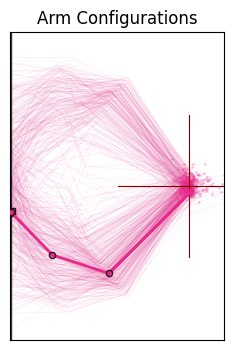

In [17]:
samples_t = workflow_dm.sample(
    conditions=obs,
    num_samples=500,
    stop_time=t_slider_backward.value
)

plot_arm_posterior(samples_t, obs, figsize=(4, 4))

print(f'Denoised Posterior at t={t_slider_backward.value}')

### Short Summary

- Diffusion models learn a time-dependent score function: $\nabla_{\boldsymbol\theta_t} \log p(\boldsymbol\theta_t\mid\mathbf{x})$, the "direction" it which we need to solve the reverse SDE
- Sample by starting from noise and iteratively denoising

This provides a highly expressive posterior approximation, especially useful for:
- multimodal posteriors,
- high-dimensional parameters,
- post-hoc modifications during inference.

## 3. Why are diffusion models so special for SBI?

Diffusion-based SBI provides two particularly useful properties. We have seen that they can tackle difficult posteriors. The real game changer is: score-based structure enables “post-hoc control”. Since diffusion models learn a conditional vector field (a *score/velocity*-like object), it is possible to modify inference after training, for example, by:
- introducing additional constraints at sampling time,
- composing information from different sources.

This idea forms the basis of *compositional inference*, which is an active research direction for building scalable [hierarchical SBI methods](https://arxiv.org/abs/2505.14429).

### Adaptation During Inference Time

The inverse-kinematics posterior is typically multimodal: multiple arm configurations can match the same end-position. The trained diffusion model supplies the conditional score

$$s_\phi(z_t,t,x) \approx \nabla_{z_t}\log p_t(z_t\mid x),$$

which points toward more probable parameter values at diffusion time $t$. From the current noisy state $z_t$, the model also forms a denoised parameter estimate $\hat\theta_0(z_t)$. We express every desired inequality as

$$c_k(\theta) \leq 0.$$

BayesFlow turns these inequalities into the smooth log-preference

$$\ell_C(\hat\theta_0,t)
= -\sum_k \operatorname{softplus}\!\left(r(t)c_k(\hat\theta_0)\right),
\qquad r(t)=\frac{\alpha_t^2}{\sigma_t^2}.$$

Here, $\operatorname{softplus}(u)=\log(1+e^u)$ is nearly zero when a constraint is comfortably satisfied and grows when $c_k>0$. The signal-to-noise scaling $r(t)$ keeps guidance weak while the state is very noisy and strengthens it as the denoised estimate becomes reliable. The sampler then uses the guided score

$$s_{\text{guided}}
=s_\phi + \lambda\,\nabla_{\hat\theta_0}\ell_C,$$

where $\lambda$ is the slider value below. Thus $\lambda=0$ recovers ordinary posterior sampling, while larger values increasingly favor the constrained region. This is soft guidance, not exact conditioning or hard rejection, so the guided samples target a deliberately modified distribution.

For the first arm angle $\theta_1$, the code uses

- **Elbow-up:** $c_{\uparrow}(\theta)=-\sin(\theta_1)\leq0$, equivalently $\sin(\theta_1)\geq0$.
- **Elbow-down:** $c_{\downarrow}(\theta)=\sin(\theta_1)\leq0$

In [18]:
def elbow_up_down_constraint(target="elbow-up"):
    """
    Constraint for guided diffusion: pick "elbow-up" or "elbow-down".

    The rule is always:
        constraint is satisfied  <=>  c(z_t) <= 0

    - If target="elbow-up":
          c(z_t) =  -sin(angle1)    -> wants sin(angle1) >= 0
    - If target="elbow-down":
          c(z_t) = sin(a1)    -> wants sin(angle1) <= 0
    """
    sign = -1.0 if target == "elbow-up" else 1.0

    def c_elbow(z):
        angle1 = z[..., 1]
        return sign * keras.ops.sin(angle1)

    return c_elbow

In [19]:
# UI controls
mode = widgets.RadioButtons(
    options=["elbow-up", "elbow-down"],
    value='elbow-up',
    description='Steering target:',
    continuous_update=True,
)

strength = widgets.FloatSlider(
    value=1.0,
    min=0,
    max=1.0,
    step=0.01,
    description='Guidance strength λ:',
    continuous_update=True,
)

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 2.98 seconds.


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 2.15 seconds.


Text(0.5, 1.0, 'Guided posterior samples (elbow-up, λ=1.0)')

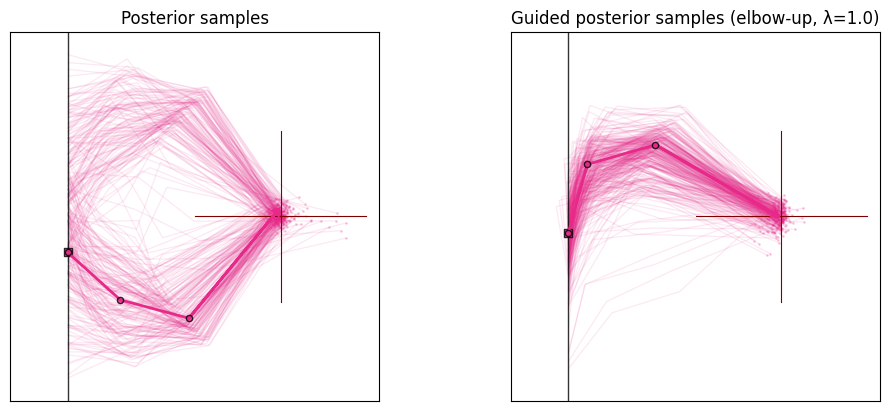

In [20]:
# Draw samples with and without guidance for side-by-side comparison
constraints = [elbow_up_down_constraint(target=str(mode.value))]

theta_unguided = workflow_dm.sample(
     conditions=obs,
     num_samples=300,
)
theta_unguided = theta_unguided['parameters'][0]

theta_guided = workflow_dm.sample(
     conditions=obs,
     num_samples=300,
     guidance_constraints=dict(
         constraints=constraints, 
         guidance_strength=float(strength.value),
     )
)
theta_guided = theta_guided['parameters'][0]

# Visualize effect on arm configurations 
fig, ax = plt.subplots(1, 2, figsize=(10, 4), subplot_kw=dict(box_aspect=1.0), layout="constrained")

model_left = InverseKinematicsModel(linecolors=["#E7298A"] * 3)   # unguided
model_right = InverseKinematicsModel(linecolors=["#E7298A"] * 3)  # guided

model_left.update_plot_ax(
    ax[0],
    theta_unguided,
    obs["observables"][0, ::-1],
    exemplar_color="#E7298A",
)
model_right.update_plot_ax(
    ax[1],
    theta_guided,
    obs["observables"][0, ::-1],
    exemplar_color="#E7298A",
)

ax[0].set_title("Posterior samples")
ax[1].set_title(f"Guided posterior samples ({mode.value}, λ={strength.value})")